# Machine Learning — Predicción de satisfacción

## Objetivo

El objetivo del modelo es predecir si un pedido entregado recibirá una valoración positiva por parte del cliente.

Se considera:

- `review_score >= 4` → satisfacción positiva (`target = 1`)
- `review_score < 4` → satisfacción negativa (`target = 0`)

## La predicción se realizará una vez entregado el pedido, permitiendo utilizar información relacionada con la experiencia de entrega.

## El modelo busca identificar qué características del pedido están más relacionadas con una experiencia positiva o negativa y evaluar si es posible anticipar la satisfacción del cliente.

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
model_df = pd.read_csv("Data_modelo_ML.csv")

In [16]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    model_df[col] = pd.to_datetime(model_df[col])

In [17]:
model_df["target"].sample()

65910    1
Name: target, dtype: int64

In [18]:
model_df = model_df.dropna(subset=["review_score"]).copy()

In [19]:
model_df["target"].value_counts()

target
1    76046
0    22627
Name: count, dtype: int64

In [20]:
model_df["target"].value_counts(normalize=True)

target
1    0.770687
0    0.229313
Name: proportion, dtype: float64

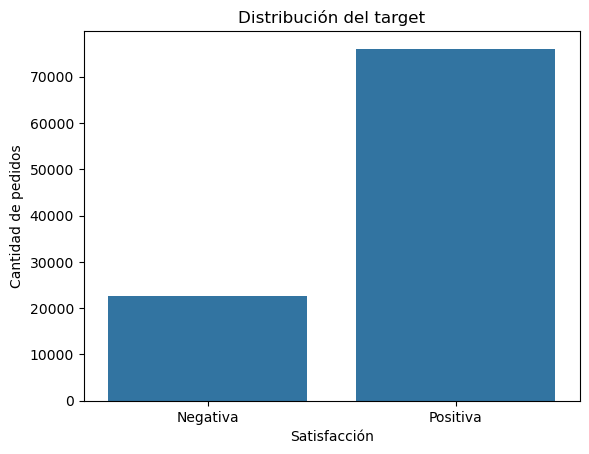

In [21]:
sns.countplot(data=model_df, x="target")

plt.title("Distribución del target")
plt.xlabel("Satisfacción")
plt.ylabel("Cantidad de pedidos")
plt.xticks([0, 1], ["Negativa", "Positiva"])

plt.show()

In [22]:
target_distribution = (
    model_df["target"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_distribution

target
0    22.931298
1    77.068702
Name: proportion, dtype: float64

# FEATURE PREPARATION

In [23]:
features = [
    "delivery_time_days",
    "delivery_delay_days",
    "is_delayed",
    "purchase_month",
    "purchase_week_day",
    "purchase_hour",
    "purchase_quarter",
    "total_order_value",
    "total_freight",
    "items_per_order",
    "freight_ratio",
    "customer_total_spent",
    "customer_avg_ticket",
    "customer_total_orders",
    "is_new_customer",
    "customer_days_since_first_purchase",
    "seller_avg_review",
    "seller_avg_delivery",
    "payment_installments",
    "product_volume",
    "seller_total_orders",
    "seller_total_sales"
]

In [24]:
X = model_df[features]
y = model_df["target"]

In [25]:
print("Filas:", model_df.shape[0])
print("Features:", X.shape[1])

print("\nDistribución del target:")
print(y.value_counts())

print("\nDistribución porcentual:")
print(y.value_counts(normalize=True))

Filas: 98673
Features: 22

Distribución del target:
target
1    76046
0    22627
Name: count, dtype: int64

Distribución porcentual:
target
1    0.770687
0    0.229313
Name: proportion, dtype: float64


In [26]:
X.isnull().sum().sort_values(ascending=False)

delivery_time_days                    2843
delivery_delay_days                   2843
seller_avg_delivery                    919
product_volume                         772
items_per_order                        756
seller_total_orders                    756
seller_avg_review                      756
freight_ratio                          756
seller_total_sales                     756
total_freight                          756
total_order_value                      756
customer_avg_ticket                    668
payment_installments                     1
purchase_quarter                         0
customer_total_orders                    0
is_new_customer                          0
customer_days_since_first_purchase       0
purchase_hour                            0
purchase_week_day                        0
purchase_month                           0
is_delayed                               0
customer_total_spent                     0
dtype: int64

# Decision:
## No se inputan los Nan. Motivo: queremos que cualquier decisión sobre los datos faltantes se aprenda solamente con el conjunto de entrenamiento

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nDistribución en Train:")
print(y_train.value_counts(normalize=True))

print("\nDistribución en Test:")
print(y_test.value_counts(normalize=True))

Train: (78938, 22)
Test: (19735, 22)

Distribución en Train:
target
1    0.770681
0    0.229319
Name: proportion, dtype: float64

Distribución en Test:
target
1    0.770712
0    0.229288
Name: proportion, dtype: float64


# BASELINE

In [31]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print(
    "Precision:",
    precision_score(y_test, y_pred_baseline, zero_division=0)
)
print(
    "Recall:",
    recall_score(y_test, y_pred_baseline, zero_division=0)
)
print(
    "F1-score:",
    f1_score(y_test, y_pred_baseline, zero_division=0)
)

Accuracy: 0.7707119331137573
Precision: 0.7707119331137573
Recall: 1.0
F1-score: 0.8705108026899413


In [33]:
print(
    classification_report(
        y_test,
        y_pred_baseline,
        target_names=["Negativa", "Positiva"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negativa       0.00      0.00      0.00      4525
    Positiva       0.77      1.00      0.87     15210

    accuracy                           0.77     19735
   macro avg       0.39      0.50      0.44     19735
weighted avg       0.59      0.77      0.67     19735



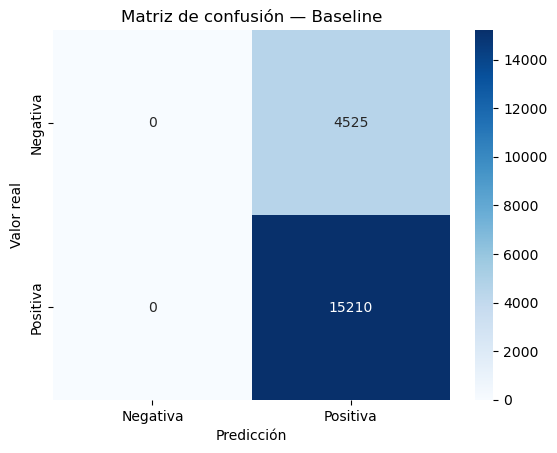

In [34]:
cm = confusion_matrix(y_test, y_pred_baseline)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negativa", "Positiva"],
    yticklabels=["Negativa", "Positiva"]
)

plt.title("Matriz de confusión — Baseline")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

## Nuestro objetivo para los modelos será:

## Maximizar la capacidad de detectar experiencias negativas (target = 0), manteniendo un nivel razonable de precisión para que las alertas sean útiles.

# LOGISTIC REGRESSION

In [36]:
logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [37]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [38]:
y_pred_logistic = logistic_pipeline.predict(X_test)

In [39]:
print(
    "Precision — Negativas:",
    precision_score(
        y_test,
        y_pred_logistic,
        pos_label=0,
        zero_division=0
    )
)

print(
    "Recall — Negativas:",
    recall_score(
        y_test,
        y_pred_logistic,
        pos_label=0,
        zero_division=0
    )
)

print(
    "F1 — Negativas:",
    f1_score(
        y_test,
        y_pred_logistic,
        pos_label=0,
        zero_division=0
    )
)

Precision — Negativas: 0.7101449275362319
Recall — Negativas: 0.25988950276243095
F1 — Negativas: 0.38052095130237823


In [40]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Negativa", "Positiva"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negativa       0.71      0.26      0.38      4525
    Positiva       0.81      0.97      0.88     15210

    accuracy                           0.81     19735
   macro avg       0.76      0.61      0.63     19735
weighted avg       0.79      0.81      0.77     19735



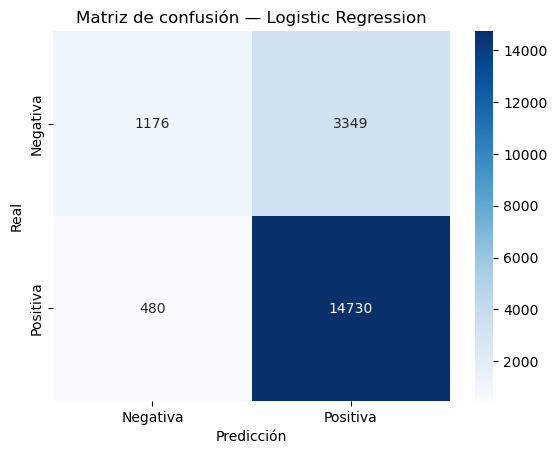

In [41]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negativa", "Positiva"],
    yticklabels=["Negativa", "Positiva"]
)

plt.title("Matriz de confusión — Logistic Regression")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

## Recall negativo = 26%
## Precision negativo = 71%

### El modelo está siendo relativamente conservador al marcar pedidos como negativos.

### Prefiere equivocarse dejando pasar algunas experiencias negativas antes que generar demasiadas falsas alarmas.
### Eso puede ser útil en determinados negocios, pero no es necesariamente lo que queremos en este proyecto.
### El objetivo es detectar la mayor cantidad posible de experiencias negativas para que la empresa pueda intervenir.

# Optimizacion Logistic

In [58]:
y_proba_logistic = logistic_pipeline.predict_proba(X_test)[:, 0]

In [59]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

results = []

for threshold in thresholds:

    y_pred_threshold = np.where(
        y_proba_logistic >= threshold,
        0,  # Negativa
        1   # Positiva
    )

    results.append({
        "threshold": threshold,
        "precision_negative": precision_score(
            y_test,
            y_pred_threshold,
            pos_label=0,
            zero_division=0
        ),
        "recall_negative": recall_score(
            y_test,
            y_pred_threshold,
            pos_label=0,
            zero_division=0
        ),
        "f1_negative": f1_score(
            y_test,
            y_pred_threshold,
            pos_label=0,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision_negative,recall_negative,f1_negative
0,0.30,0.536617,0.370829,0.438578
1,0.35,0.601237,0.322210,0.419568
2,0.40,0.650661,0.293481,0.404508
3,0.45,0.686641,0.276022,0.393758
4,0.50,0.710145,0.259890,0.380521
5,0.55,0.731952,0.241989,0.363727
6,0.60,0.759091,0.221436,0.342857


# RANDOMFOREST

In [44]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [45]:
rf_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,200


In [46]:
y_pred_rf = rf_pipeline.predict(X_test)

In [47]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Negativa", "Positiva"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negativa       0.75      0.33      0.46      4525
    Positiva       0.83      0.97      0.89     15210

    accuracy                           0.82     19735
   macro avg       0.79      0.65      0.68     19735
weighted avg       0.81      0.82      0.79     19735



In [48]:
print(
    "Precision — Negativas:",
    precision_score(
        y_test,
        y_pred_rf,
        pos_label=0,
        zero_division=0
    )
)

print(
    "Recall — Negativas:",
    recall_score(
        y_test,
        y_pred_rf,
        pos_label=0,
        zero_division=0
    )
)

print(
    "F1 — Negativas:",
    f1_score(
        y_test,
        y_pred_rf,
        pos_label=0,
        zero_division=0
    )
)

Precision — Negativas: 0.7548676984523215
Recall — Negativas: 0.33414364640883976
F1 — Negativas: 0.4632352941176471


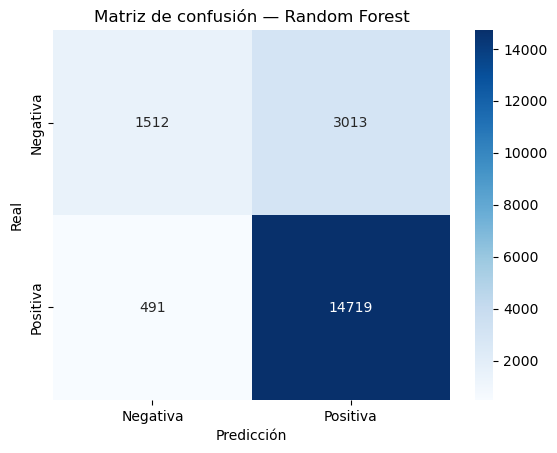

In [49]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negativa", "Positiva"],
    yticklabels=["Negativa", "Positiva"]
)

plt.title("Matriz de confusión — Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

## Random Forest detecta aproximadamente:

### 4.525 × 0.33 ≈ 1.493 experiencias negativas

frente a unas:

### 4.525 × 0.26 ≈ 1.177

de Logistic Regression.

### Es decir, Random Forest consigue encontrar unas 316 experiencias negativas adicionales sobre el mismo conjunto de test.

### Además, cuando predice una experiencia negativa, acierta aproximadamente el 75% de las veces.

# Queremos explorar:

## ¿Qué ocurre si estamos dispuestos a generar más alertas con tal de detectar más experiencias negativas?

## Para eso necesitamos las probabilidades, no las predicciones.

In [50]:
y_proba_rf = rf_pipeline.predict_proba(X_test)

In [54]:
y_proba_negative = rf_pipeline.predict_proba(X_test)[:, 0]

In [55]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

results = []

for threshold in thresholds:

    y_pred_threshold = np.where(
        y_proba_negative >= threshold,
        0,  # Negativa
        1   # Positiva
    )

    results.append({
        "threshold": threshold,
        "precision_negative": precision_score(
            y_test,
            y_pred_threshold,
            pos_label=0,
            zero_division=0
        ),
        "recall_negative": recall_score(
            y_test,
            y_pred_threshold,
            pos_label=0,
            zero_division=0
        ),
        "f1_negative": f1_score(
            y_test,
            y_pred_threshold,
            pos_label=0,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision_negative,recall_negative,f1_negative
0,0.30,0.484676,0.527735,0.505290
1,0.35,0.561098,0.469834,0.511427
2,0.40,0.639389,0.416133,0.504150
3,0.45,0.706081,0.369503,0.485130
4,0.50,0.754868,0.334144,0.463235
5,0.55,0.801536,0.299890,0.436475
6,0.60,0.832418,0.267845,0.405283


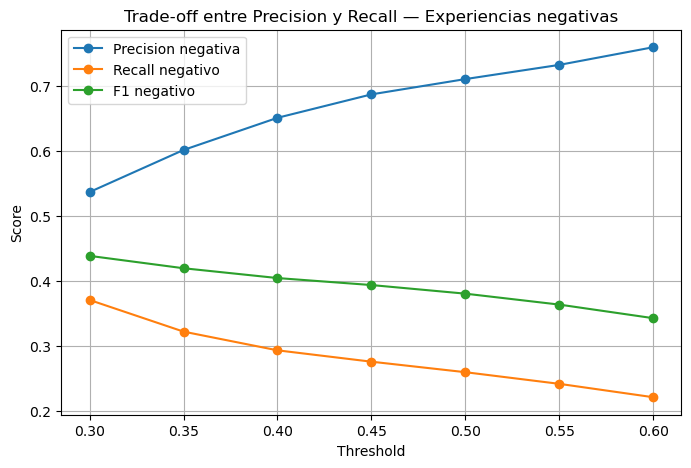

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision_negative"],
    marker="o",
    label="Precision negativa"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall_negative"],
    marker="o",
    label="Recall negativo"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1_negative"],
    marker="o",
    label="F1 negativo"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Trade-off entre Precision y Recall — Experiencias negativas")
plt.legend()
plt.grid()

plt.show()

# Las tres curvas representan:

# 🔵 Precision negativa: de las que marcamos como negativas, cuántas realmente lo son.
# 🟠 Recall negativo: de todas las experiencias realmente negativas, cuántas conseguimos detectar.
# 🟢 F1 negativo: equilibrio entre Precision y Recall.

## Pasamos de detectar aproximadamente 1 de cada 3 experiencias negativas a detectar más de la mitad.

## El coste es que la precision baja de 75.5% → 48.5%.

# El Random Forest fue seleccionado como modelo final debido a que presentó el mejor desempeño para identificar experiencias negativas. Se estableció un threshold de 0.35, priorizando la detección de casos negativos pero manteniendo un equilibrio razonable entre recall y precision.

# ¿Por qué 0.35 es interesante?

Porque en nuestro caso no queremos maximizar simplemente Precision ni Recall.

Nuestro objetivo es:

## Detectar experiencias negativas sin generar un número excesivo de falsas alertas.

El gráfico muestra que:

0.35 → F1 = 0.511, el máximo entre los thresholds evaluados.

Por eso podemos justificar:

Se seleccionó un threshold de 0.35 debido a que presentó el mayor F1-score para la clase negativa entre los valores evaluados, proporcionando un equilibrio entre la detección de experiencias negativas (Recall = 47%) y la confiabilidad de las alertas (Precision = 56%).


# Traducción a negocio:

"El modelo permite identificar aproximadamente 47 de cada 100 experiencias que terminarían siendo negativas. De las experiencias que el modelo señala como potencialmente negativas, aproximadamente 56 de cada 100 efectivamente presentan una valoración negativa. Esto permite priorizar clientes potencialmente insatisfechos para acciones de seguimiento, aceptando cierto nivel de falsas alertas."